<a href="https://colab.research.google.com/github/isadorapandas/data-science-visualizacao-de-dados/blob/main/Visualizacao_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/alura-cursos/bibliotecas_visualizacao/refs/heads/main/Dados/imigrantes_canada.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 38 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   País        195 non-null    object
 1   Continente  195 non-null    object
 2   Região      195 non-null    object
 3   1980        195 non-null    int64 
 4   1981        195 non-null    int64 
 5   1982        195 non-null    int64 
 6   1983        195 non-null    int64 
 7   1984        195 non-null    int64 
 8   1985        195 non-null    int64 
 9   1986        195 non-null    int64 
 10  1987        195 non-null    int64 
 11  1988        195 non-null    int64 
 12  1989        195 non-null    int64 
 13  1990        195 non-null    int64 
 14  1991        195 non-null    int64 
 15  1992        195 non-null    int64 
 16  1993        195 non-null    int64 
 17  1994        195 non-null    int64 
 18  1995        195 non-null    int64 
 19  1996        195 non-null    int64 
 20  1997      

In [4]:
# analisar as tendências de imigração do Brasil ao longo dos anos
# vamos alterar o index do nosso dataframe para ser o país

df.set_index('País', inplace=True)

In [5]:
# vamos criar a variável anos igual à lista com os intervalos de ano. Ou seja, usamos a função list() e, nela,
# colocamos a função map(), porque vamos pedir para que os valores fiquem em string. Desse modo, vamos ter os valores como objetos e não como números
anos = list(map(str, range(1980, 2014)))

In [6]:
# queremos pegar somente os dados do Brasil
# Podemos usar a loc do Pandas para fazer isso, pois essa propriedade consegue pegar rótulos específicos dentro de um dataframe
brasil = df.loc['Brasil', anos]

In [7]:
brasil

,Brasil
1980,211
1981,220
1982,192
1983,139
1984,145
1985,130
1986,205
1987,244
1988,394
1989,650


In [8]:
brasil_dict = {'ano': brasil.index.tolist(), 'imigrantes': brasil.values.tolist()} # dicionário, que irá virar um dataframe
dados_brasil = pd.DataFrame(brasil_dict)

In [9]:
dados_brasil

,ano,imigrantes
0,1980,211
1,1981,220
2,1982,192
3,1983,139
4,1984,145
5,1985,130
6,1986,205
7,1987,244
8,1988,394
9,1989,650


In [10]:
import matplotlib.pyplot as plt

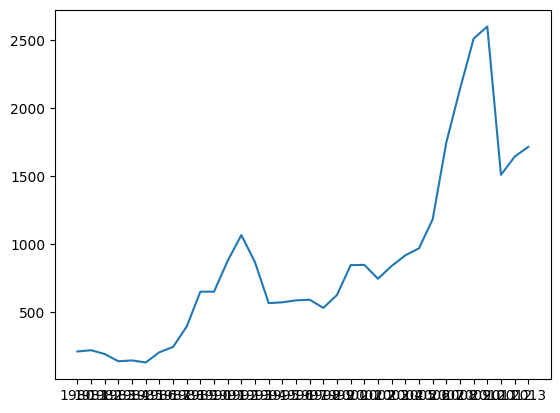

In [11]:
plt.plot(dados_brasil['ano'], dados_brasil['imigrantes'])

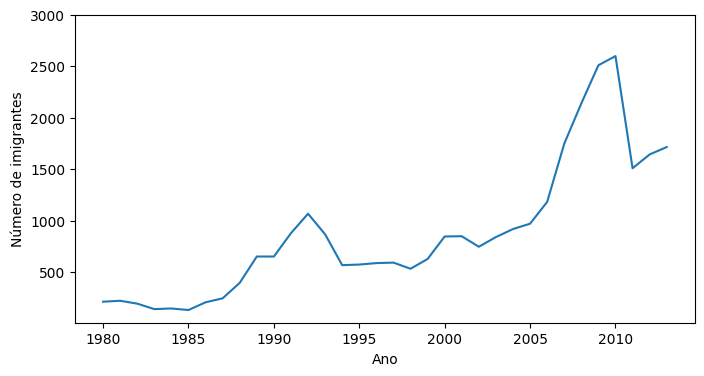

In [12]:
plt.figure(figsize=(8,4))
plt.plot(dados_brasil['ano'], dados_brasil['imigrantes'])
plt.xlabel('Ano')
plt.ylabel('Número de imigrantes')
plt.xticks(['1980', '1985', '1990', '1995', '2000', '2005', '2010']) # função xticks() que se refere as marcações do eixo x
plt.yticks([500, 1000, 1500, 2000, 2500, 3000]) # marcações do eixo y
plt.show()
# códigos escritos abaixo de plt.show() não serão executados, pois o Python interrompe a execução dos códigos

In [13]:
df_comparacao = df.loc[['Brasil', 'Argentina'], anos]
df_comparacao

,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
País,,,,,,,,,,,,,,,,,,,,,
Brasil,211,220,192,139,145,130,205,244,394,650,...,917,969,1181,1746,2138,2509,2598,1508,1642,1714
Argentina,368,426,626,241,237,196,213,519,374,538,...,1591,1153,847,620,540,467,459,278,263,282


In [14]:
df_comparacao = df_comparacao.T # transpose

# Como resultado temos uma coluna com os anos e duas colunas para cada país contendo o número de imigrantes.

df_comparacao.head()

País,Brasil,Argentina
1980,211,368
1981,220,426
1982,192,626
1983,139,241
1984,145,237


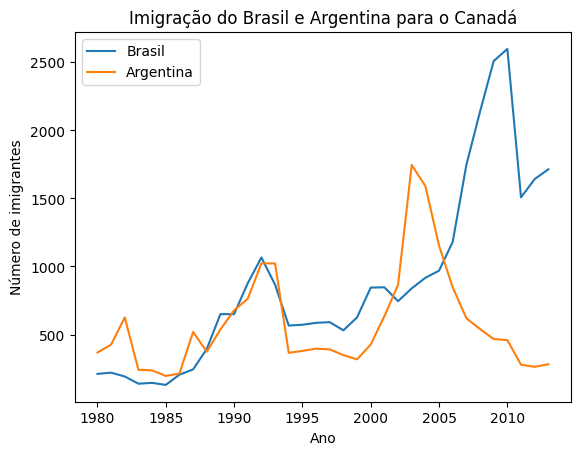

In [15]:
plt.plot(df_comparacao['Brasil'], label = 'Brasil')
plt.plot(df_comparacao['Argentina'], label ='Argentina')
plt.title('Imigração do Brasil e Argentina para o Canadá')
plt.xlabel('Ano')
plt.ylabel('Número de imigrantes')
plt.xticks(['1980', '1985', '1990', '1995', '2000', '2005', '2010'])
plt.legend()
plt.show()

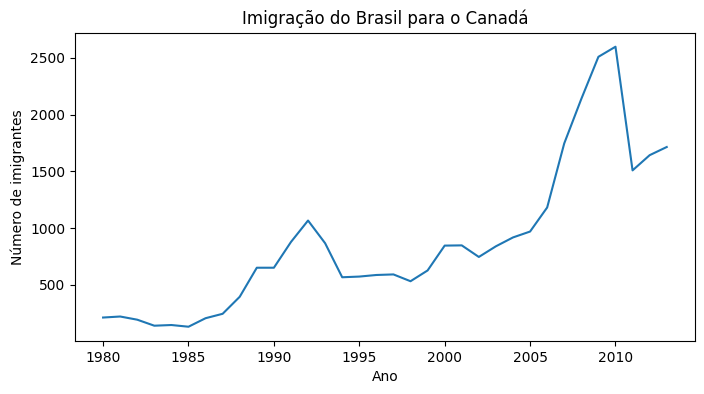

In [16]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(dados_brasil['ano'], dados_brasil['imigrantes'])
ax.set_title('Imigração do Brasil para o Canadá')
ax.set_xlabel('Ano')
ax.set_ylabel('Número de imigrantes')
ax.xaxis.set_major_locator(plt.MultipleLocator(5)) # com set_major_locator() conseguimos modificar o eixo x para o intervalo de 5 em 5 anos
plt.show()

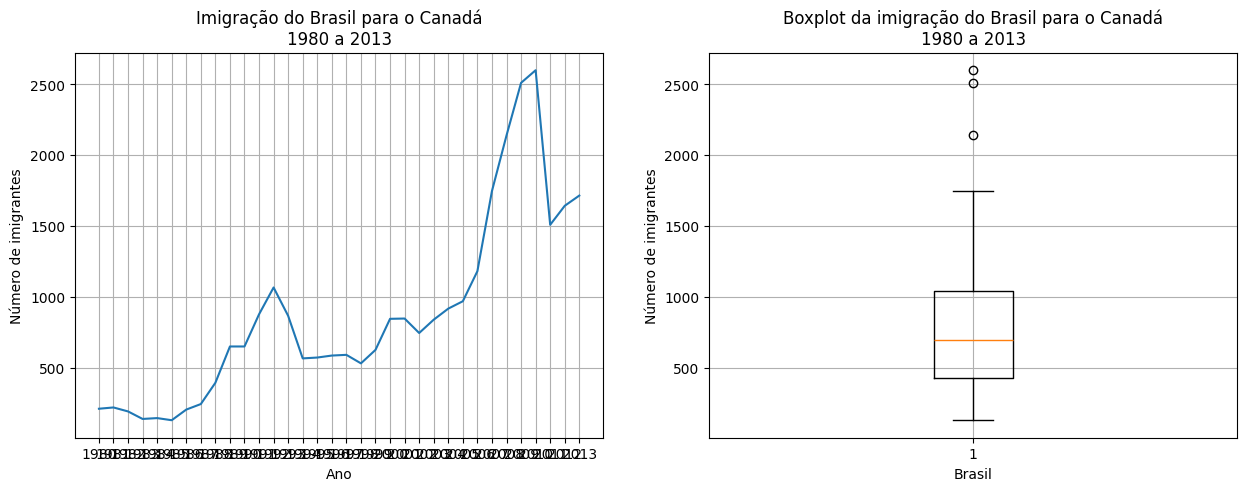

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5)) # criando dois subplots

# primeiro subplot
axs[0].plot(dados_brasil['ano'], dados_brasil['imigrantes'])
axs[0].set_title('Imigração do Brasil para o Canadá\n1980 a 2013')
axs[0].set_xlabel('Ano')
axs[0].set_ylabel('Número de imigrantes')
axs[0].xaxis.set_major_locator
axs[0].grid()

# segundo subplot
axs[1].boxplot(dados_brasil['imigrantes'])
axs[1].set_title('Boxplot da imigração do Brasil para o Canadá\n1980 a 2013')
axs[1].set_xlabel('Brasil')
axs[1].set_ylabel('Número de imigrantes')
axs[1].grid()

plt.show()


In [18]:
dados_brasil.describe()

,imigrantes
count,34.000000
mean,872.323529
std,663.401232
min,130.000000
25%,428.250000
50%,697.500000
75%,1041.750000
max,2598.000000


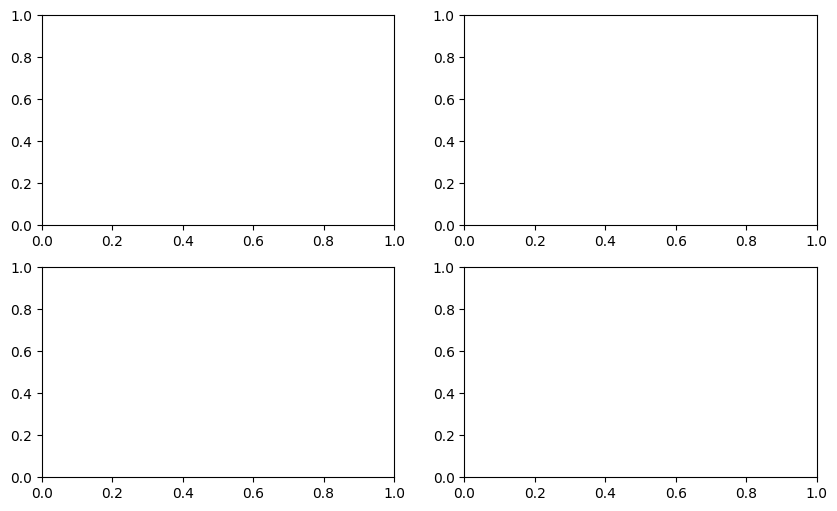

In [19]:
fig, axs = plt.subplots(2,2, figsize=(10,6)) # criando 4 subplots em 2 direções

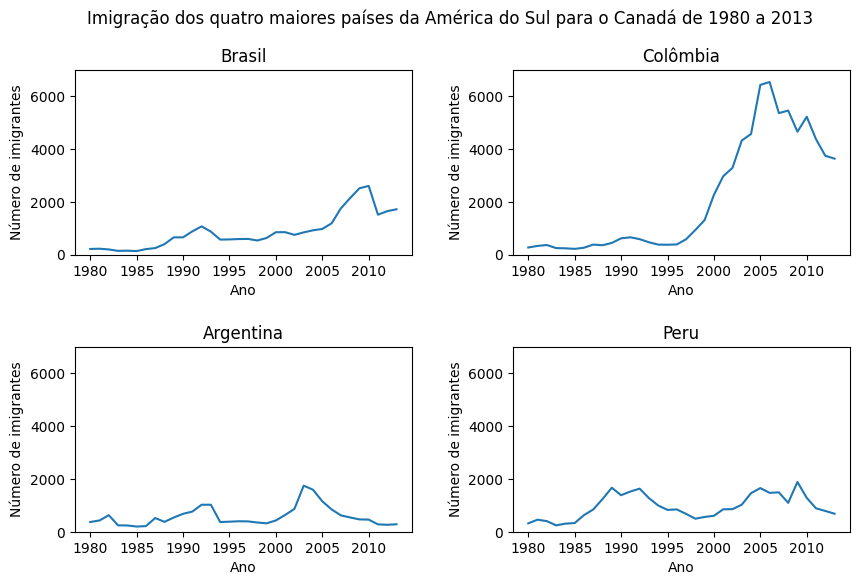

In [20]:
fig, axs = plt.subplots(2,2, figsize=(10,6))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
fig.suptitle('Imigração dos quatro maiores países da América do Sul para o Canadá de 1980 a 2013')

# subplot da fileira 1 e coluna 1
axs[0,0].plot(df.loc['Brasil', anos])
axs[0,0].set_title('Brasil')

# subplot da fileira 1 e coluna 2
axs[0,1].plot(df.loc['Colômbia', anos])
axs[0,1].set_title('Colômbia')

# subplot da fileira 2 e coluna 1
axs[1,0].plot(df.loc['Argentina', anos])
axs[1,0].set_title('Argentina')

# subplot da fileira 2 e coluna 2
axs[1,1].plot(df.loc['Peru', anos])
axs[1,1].set_title('Peru')

# insere o intervalo de 5 em 5 anos para os 4 subplots
for ax in axs.flat:
  ax.xaxis.set_major_locator(plt.MultipleLocator(5))

# adiciona rótulo para os 4 sublplots
for ax in axs.flat:
  ax.set_xlabel('Ano')
  ax.set_ylabel('Número de imigrantes')

ymin = 0
ymax = 7000

# defini limite para o eixo y nos 4 subplots
for ax in axs.ravel():
  ax.set_ylim(ymin, ymax)

plt.show()

In [21]:
# criar uma figura com subplots que apresente a variação no número de vendas em quatro diferentes lojas ao longo de um ano

lojas = ['A', 'B', 'C', 'D']

vendas_2022 = {'Jan': [100, 80, 150, 50],
    'Fev': [120, 90, 170, 60],
    'Mar': [150, 100, 200, 80],
    'Abr': [180, 110, 230, 90],
    'Mai': [220, 190, 350, 200],
    'Jun': [230, 150, 280, 120],
    'Jul': [250, 170, 300, 140],
    'Ago': [260, 180, 310, 150],
    'Set': [240, 160, 290, 130],
    'Out': [220, 140, 270, 110],
    'Nov': [400, 220, 350, 190],
    'Dez': [300, 350, 400, 250]
}

df = pd.DataFrame(vendas_2022, index=lojas)

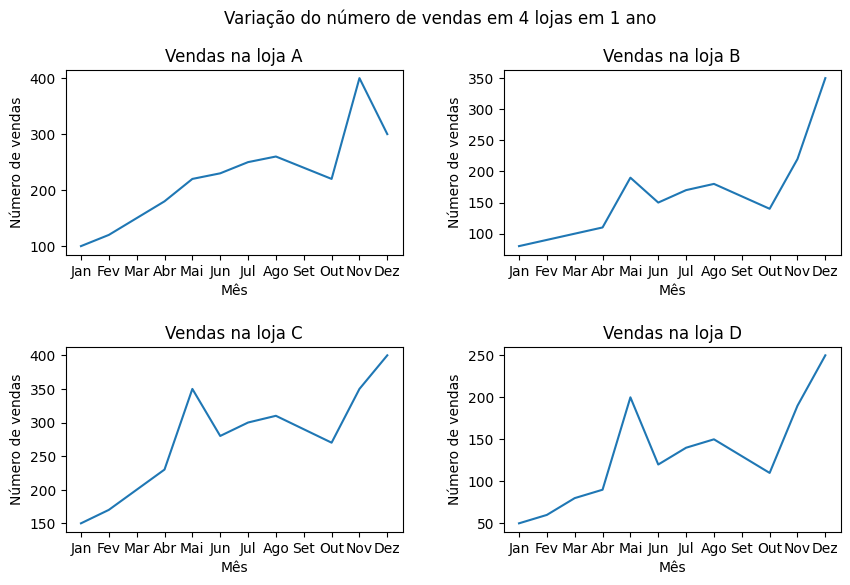

In [22]:
fig, axs = plt.subplots(2,2, figsize=(10,6))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
fig.suptitle('Variação do número de vendas em 4 lojas em 1 ano')

# subplot da fileira 1 e coluna 1
axs[0,0].plot(df.loc['A'])
axs[0,0].set_title('Vendas na loja A')

# subplot da fileira 1 e coluna 2
axs[0,1].plot(df.loc['B'])
axs[0,1].set_title('Vendas na loja B')

# subplot da fileira 2 e coluna 1
axs[1,0].plot(df.loc['C'])
axs[1,0].set_title('Vendas na loja C')

# subplot da fileira 2 e coluna 2
axs[1,1].plot(df.loc['D'])
axs[1,1].set_title('Vendas na loja D')

# Adicionando rótulos para os eixos X e Y
for ax in axs.flat:
    ax.set_xlabel('Mês')
    ax.set_ylabel('Número de vendas')

plt.show()

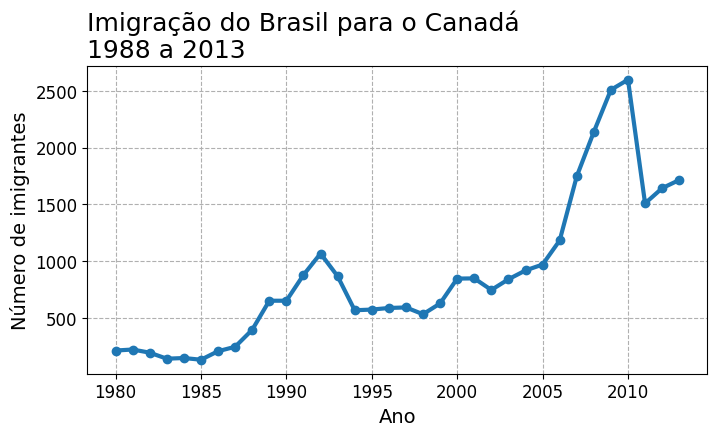

In [23]:
# adicionando configurações visuais
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(dados_brasil['ano'], dados_brasil['imigrantes'], lw=3, marker='o')
ax.set_title('Imigração do Brasil para o Canadá\n1988 a 2013', fontsize=18, loc='left')
ax.set_xlabel('Ano', fontsize=14)
ax.set_ylabel('Número de imigrantes', fontsize=14)
ax.xaxis.set_tick_params(labelsize=12)
ax.yaxis.set_tick_params(labelsize=12)
ax.xaxis.set_major_locator(plt.MultipleLocator(5))
plt.grid()
plt.grid(linestyle='--')
plt.show()

In [24]:
# escolhendo um estilo
print(plt.style.available)
IPython_default = plt.rcParams.copy()
plt.style.use('fivethirtyeight')

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


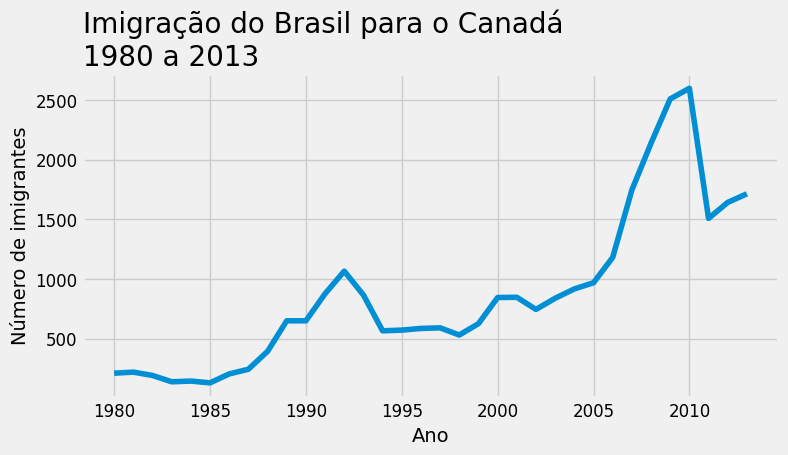

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(dados_brasil['ano'], dados_brasil['imigrantes'])
ax.set_title('Imigração do Brasil para o Canadá\n1980 a 2013', fontsize=20, loc='left')
ax.set_ylabel('Número de imigrantes', fontsize=14)
ax.set_xlabel('Ano', fontsize=14)
ax.yaxis.set_tick_params(labelsize=12)
ax.xaxis.set_tick_params(labelsize=12)
ax.xaxis.set_major_locator(plt.MultipleLocator(5))
plt.show()


In [26]:
# redefinindo os parâmetros utilizando rcParams.update e passando a ele a variável IPython_default
plt.rcParams.update(IPython_default);

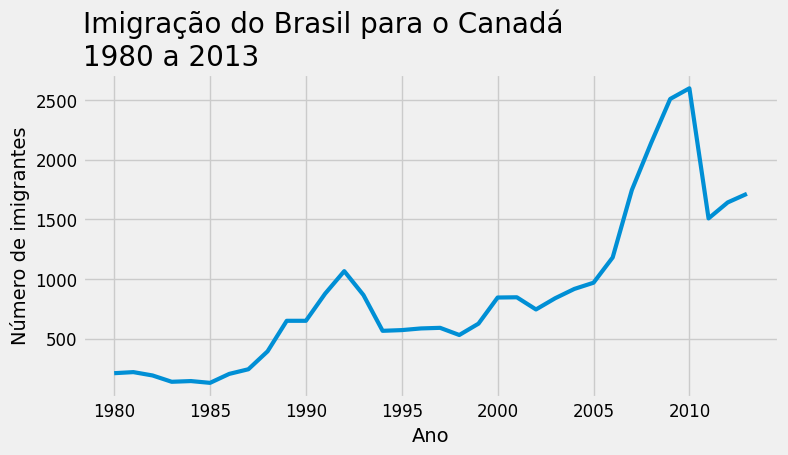

In [27]:
#  aplicando um estilo apenas a um bloco de código específico
with plt.style.context('fivethirtyeight'):
  fig, ax = plt.subplots(figsize=(8, 4))
  ax.plot(dados_brasil['ano'], dados_brasil['imigrantes'], lw=3)
  ax.set_title('Imigração do Brasil para o Canadá\n1980 a 2013', fontsize=20, loc='left')
  ax.set_ylabel('Número de imigrantes', fontsize=14)
  ax.set_xlabel('Ano', fontsize=14)
  ax.yaxis.set_tick_params(labelsize=12)
  ax.xaxis.set_tick_params(labelsize=12)
  ax.xaxis.set_major_locator(plt.MultipleLocator(5))
  plt.show()

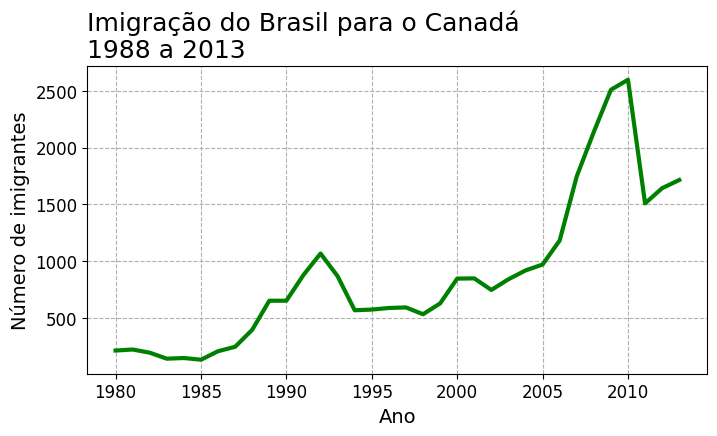

In [28]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(dados_brasil['ano'], dados_brasil['imigrantes'], lw=3, color='g')
ax.set_title('Imigração do Brasil para o Canadá\n1988 a 2013', fontsize=18, loc='left')
ax.set_xlabel('Ano', fontsize=14)
ax.set_ylabel('Número de imigrantes', fontsize=14)
ax.xaxis.set_tick_params(labelsize=12)
ax.yaxis.set_tick_params(labelsize=12)
ax.xaxis.set_major_locator(plt.MultipleLocator(5))
plt.grid(linestyle='--')
plt.show()

In [29]:
# reiniciando a base dos paises
df = pd.read_csv("https://raw.githubusercontent.com/alura-cursos/bibliotecas_visualizacao/refs/heads/main/Dados/imigrantes_canada.csv")
df.head()

,País,Continente,Região,1980,1981,1982,1983,1984,1985,1986,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
0,Afeganistão,Ásia,Sul da Ásia,16,39,39,47,71,340,496,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
1,Albânia,Europa,Sul da Europa,1,0,0,0,0,0,1,...,1223,856,702,560,716,561,539,620,603,15699
2,Argélia,África,Norte da África,80,67,71,69,63,44,69,...,3626,4807,3623,4005,5393,4752,4325,3774,4331,69439
3,Samoa Americana,Oceânia,Polinésia,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,6
4,Andorra,Europa,Sul da Europa,0,0,0,0,0,0,2,...,0,1,1,0,0,0,0,1,1,15


In [30]:
df.set_index('País', inplace=True)

In [31]:
# filtrando os países da america do sul
america_sul = df.query('Região == "América do Sul"')
america_sul

,Continente,Região,1980,1981,1982,1983,1984,1985,1986,1987,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
País,,,,,,,,,,,,,,,,,,,,,
Argentina,América Latina e o Caribe,América do Sul,368,426,626,241,237,196,213,519,...,1153,847,620,540,467,459,278,263,282,19596
Bolívia,América Latina e o Caribe,América do Sul,44,52,42,49,38,44,79,165,...,134,139,107,143,214,180,86,83,107,3205
Brasil,América Latina e o Caribe,América do Sul,211,220,192,139,145,130,205,244,...,969,1181,1746,2138,2509,2598,1508,1642,1714,29659
Chile,América Latina e o Caribe,América do Sul,1233,1069,1078,781,681,533,633,1454,...,384,427,530,350,375,340,174,291,273,21359
Colômbia,América Latina e o Caribe,América do Sul,266,326,360,244,235,214,257,376,...,6424,6535,5357,5452,4652,5218,4366,3741,3631,72088
Equador,América Latina e o Caribe,América do Sul,238,207,184,155,179,208,240,344,...,491,525,419,437,373,353,348,282,418,12233
Guiana,América Latina e o Caribe,América do Sul,2334,2943,3575,2650,1932,2299,3942,6174,...,1215,1286,1277,1137,1180,953,804,676,656,75785
Paraguai,América Latina e o Caribe,América do Sul,45,26,32,40,48,36,34,72,...,75,88,98,95,88,89,83,55,66,1944
Peru,América Latina e o Caribe,América do Sul,317,456,401,241,306,328,628,843,...,1653,1473,1490,1094,1884,1283,886,787,682,32652


In [32]:
# cores diferentes para cada barra
cores = ['royalblue', 'orange', 'forestgreen', 'orchid', 'purple', 'brown', 'slateblue', 'gray', 'olive', 'navy', 'teal', 'tomato']

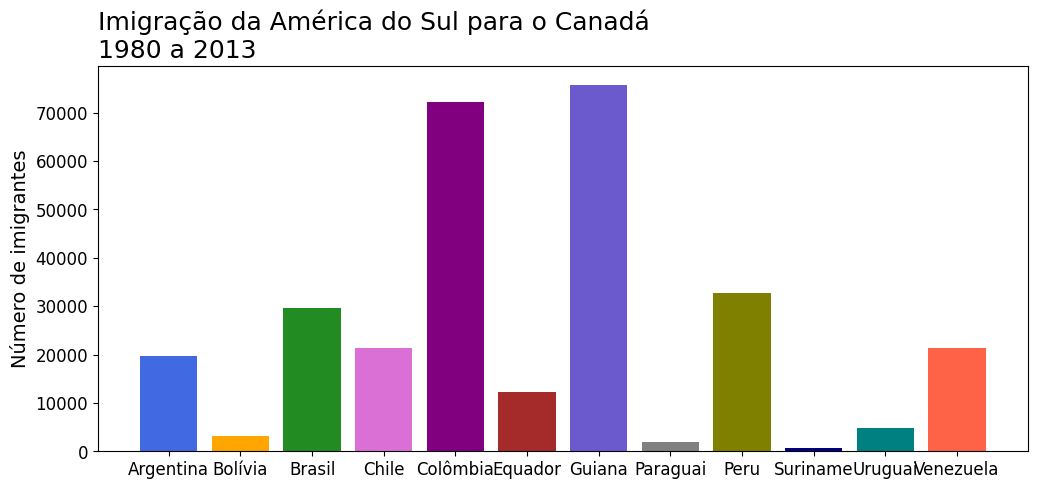

In [33]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(america_sul.index, america_sul['Total'], color=cores)
ax.set_title('Imigração da América do Sul para o Canadá\n1980 a 2013', loc='left', fontsize=18)
ax.set_ylabel('Número de imigrantes', fontsize=14)
ax.set_xlabel('')
ax.yaxis.set_tick_params(labelsize=12)
ax.xaxis.set_tick_params(labelsize=12)

plt.show()

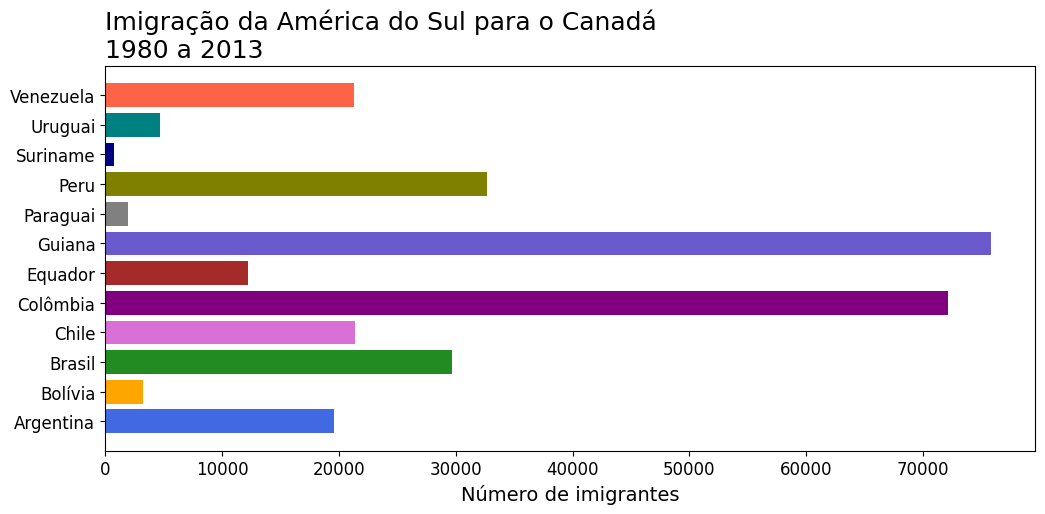

In [34]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(america_sul.index, america_sul['Total'], color=cores) # barra na horizontal
ax.set_title('Imigração da América do Sul para o Canadá\n1980 a 2013', loc='left', fontsize=18)
ax.set_ylabel('')
ax.set_xlabel('Número de imigrantes', fontsize=14)
ax.yaxis.set_tick_params(labelsize=12)
ax.xaxis.set_tick_params(labelsize=12)

plt.show()

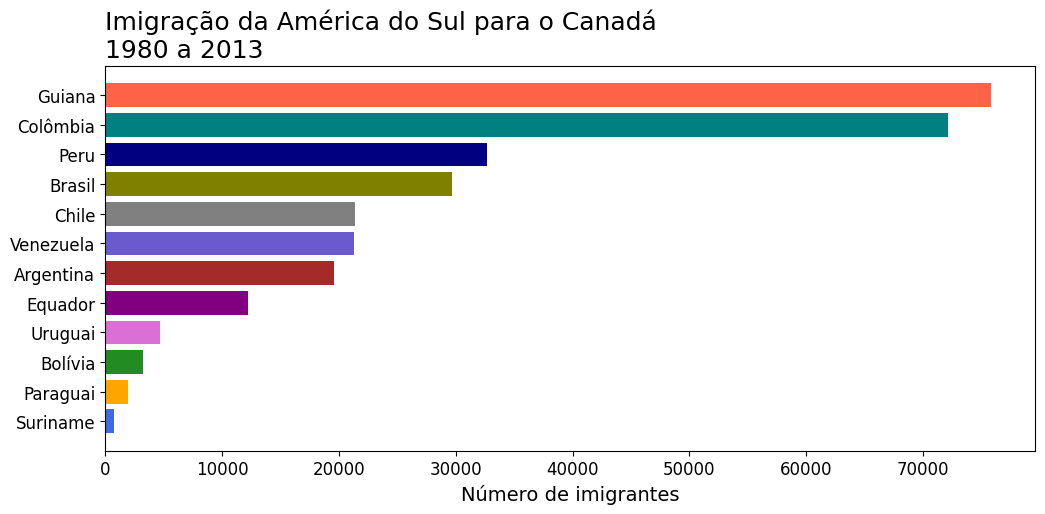

In [35]:
america_sul_sorted = america_sul.sort_values('Total', ascending=True) # ordenando do maior pro menor

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(america_sul_sorted.index, america_sul_sorted['Total'], color=cores) # barra na horizontal
ax.set_title('Imigração da América do Sul para o Canadá\n1980 a 2013', loc='left', fontsize=18)
ax.set_ylabel('')
ax.set_xlabel('Número de imigrantes', fontsize=14)
ax.yaxis.set_tick_params(labelsize=12)
ax.xaxis.set_tick_params(labelsize=12)

plt.show()

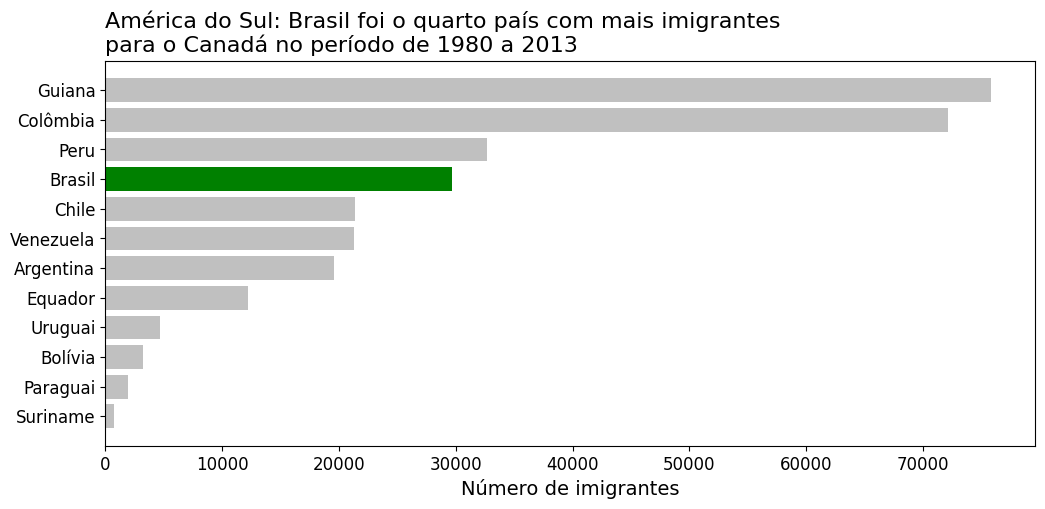

In [36]:
cores = []
for pais in america_sul_sorted.index:
    if pais == 'Brasil':
        cores.append('green') # se for brasil, fica verde
    else:
        cores.append('silver') # se não, fica cinza

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(america_sul_sorted.index, america_sul_sorted['Total'], color=cores)
ax.set_title('América do Sul: Brasil foi o quarto país com mais imigrantes\npara o Canadá no período de 1980 a 2013', loc='left', fontsize=16)
ax.set_xlabel('Número de imigrantes', fontsize=14)
ax.set_ylabel('')
ax.yaxis.set_tick_params(labelsize=12)
ax.xaxis.set_tick_params(labelsize=12)

plt.show()

In [37]:
america_sul_sorted['Total']

,Total
País,
Suriname,739
Paraguai,1944
Bolívia,3205
Uruguai,4715
Equador,12233
Argentina,19596
Venezuela,21267
Chile,21359
Brasil,29659


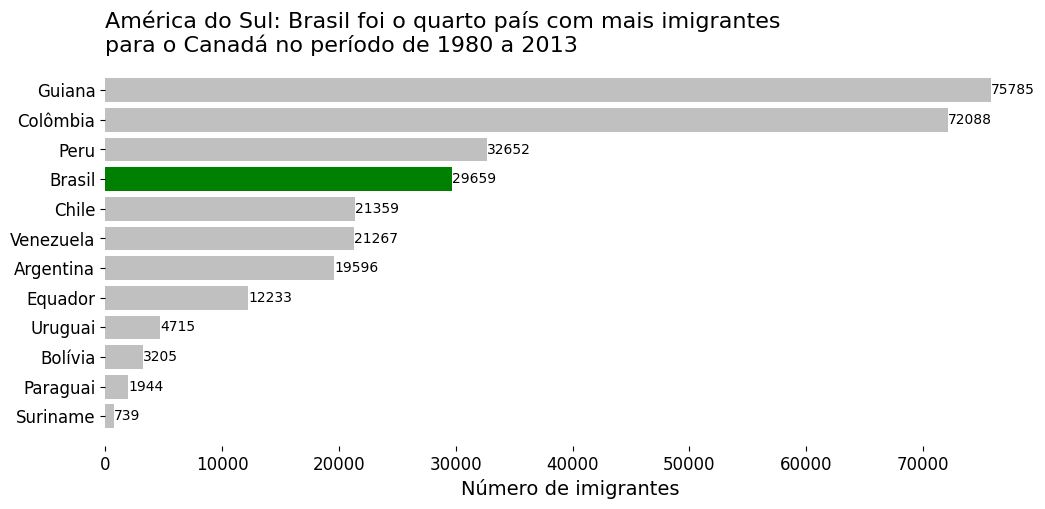

In [38]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(america_sul_sorted.index, america_sul_sorted['Total'], color=cores)
ax.set_title('América do Sul: Brasil foi o quarto país com mais imigrantes\npara o Canadá no período de 1980 a 2013', loc='left', fontsize=16)
ax.set_xlabel('Número de imigrantes', fontsize=14)
ax.set_ylabel('')
ax.yaxis.set_tick_params(labelsize=12)
ax.xaxis.set_tick_params(labelsize=12)

for i, v in enumerate(america_sul_sorted['Total']):
    ax.text(v + 20, i, str(v), color='black', fontsize=10, ha='left', va='center')
# Dentro do text(), v + 20 indica a posição onde o texto será adicionado, v corresponde a cada uma das barras (indice) e i é a posição Y do texto (q corresponde ao numeros de imigrantes de cada país)
# Por fim, usamos o str() para indicar que vamos converter o tamanho de cada barra em uma string, que será o nosso texto.

ax.set_frame_on(False) # remove as linhas da "caixa"

plt.show()


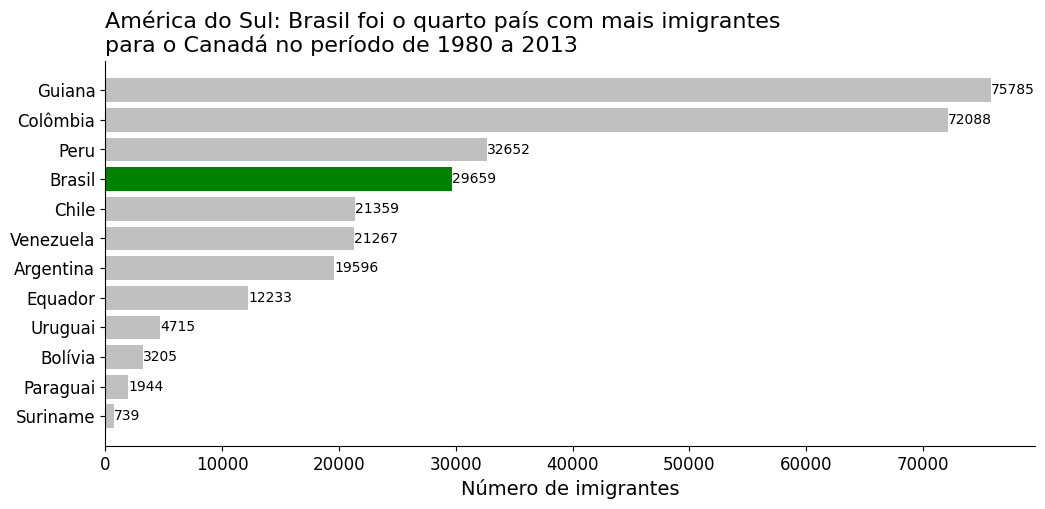

In [39]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(america_sul_sorted.index, america_sul_sorted['Total'], color=cores)
ax.set_title('América do Sul: Brasil foi o quarto país com mais imigrantes\npara o Canadá no período de 1980 a 2013', loc='left', fontsize=16)
ax.set_xlabel('Número de imigrantes', fontsize=14)
ax.set_ylabel('')
ax.yaxis.set_tick_params(labelsize=12)
ax.xaxis.set_tick_params(labelsize=12)

for i, v in enumerate(america_sul_sorted['Total']):
    ax.text(v + 20, i, str(v), color='black', fontsize=10, ha='left', va='center')
# Dentro do text(), v + 20 indica a posição onde o texto será adicionado, v corresponde a cada uma das barras (indice) e i é a posição Y do texto (q corresponde ao numeros de imigrantes de cada país)
# Por fim, usamos o str() para indicar que vamos converter o tamanho de cada barra em uma string, que será o nosso texto.

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()


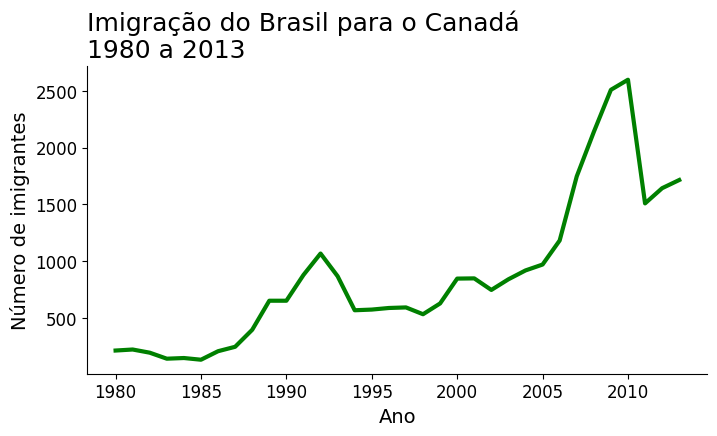

In [40]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(dados_brasil['ano'], dados_brasil['imigrantes'], lw=3, color='g')
ax.set_title('Imigração do Brasil para o Canadá\n1980 a 2013', fontsize=18, loc='left')
ax.set_xlabel('Ano', fontsize=14)
ax.set_ylabel('Número de imigrantes', fontsize=14)
ax.yaxis.set_tick_params(labelsize=12)
ax.xaxis.set_tick_params(labelsize=12)
ax.xaxis.set_major_locator(plt.MultipleLocator(5))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig('imigracao_brasil_canada.png', transparent=False, dpi=300, bbox_inches='tight')

plt.show()

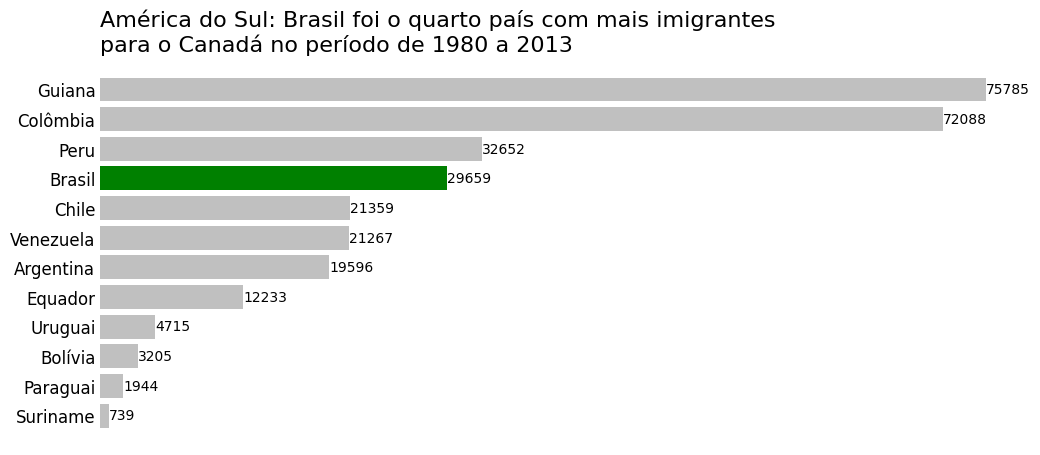

In [41]:
cores = []
for pais in america_sul_sorted.index:
    if pais == 'Brasil':
        cores.append('green')
    else:
        cores.append('silver')

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(america_sul_sorted.index, america_sul_sorted['Total'], color=cores)
ax.set_title('América do Sul: Brasil foi o quarto país com mais imigrantes\npara o Canadá no período de 1980 a 2013', loc='left', fontsize=16)
ax.set_xlabel('Número de imigrantes', fontsize=14)
ax.set_ylabel('')
ax.yaxis.set_tick_params(labelsize=12)
ax.xaxis.set_tick_params(labelsize=12)

for i, v in enumerate(america_sul_sorted['Total']):
    ax.text(v + 20, i, str(v), color='black', fontsize=10, ha='left', va='center')

ax.set_frame_on(False)
ax.get_xaxis().set_visible(False)
ax.tick_params(axis='both', which='both', length=0)

fig.savefig('imigracao_america_sul.png', transparent=False, dpi=300, bbox_inches='tight') # salva a imagem na pasta

plt.show()

In [42]:
lojas = ['A', 'B', 'C', 'D']

vendas_2022 = {'Jan': [100, 80, 150, 50],
    'Fev': [120, 90, 170, 60],
    'Mar': [150, 100, 200, 80],
    'Abr': [180, 110, 230, 90],
    'Mai': [220, 190, 350, 200],
    'Jun': [230, 150, 280, 120],
    'Jul': [250, 170, 300, 140],
    'Ago': [260, 180, 310, 150],
    'Set': [240, 160, 290, 130],
    'Out': [220, 140, 270, 110],
    'Nov': [400, 220, 350, 190],
    'Dez': [300, 350, 400, 250]
}

# Criando DataFrame
df = pd.DataFrame(vendas_2022, index=lojas)

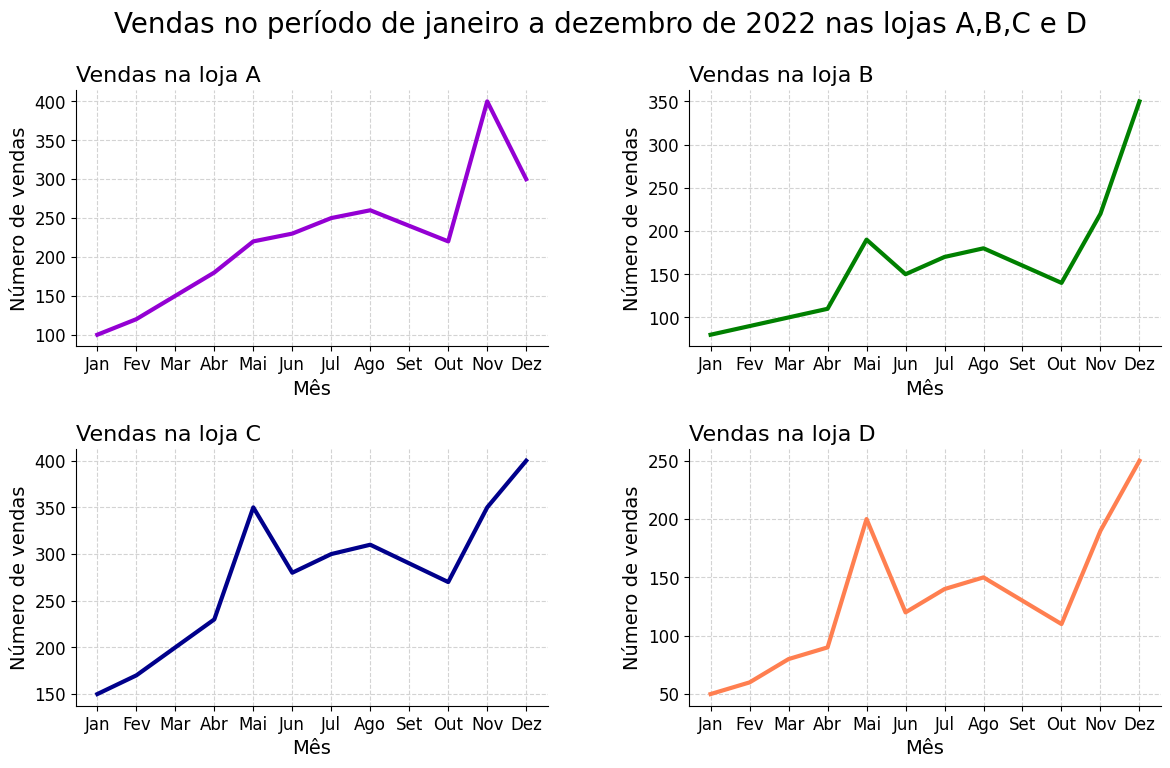

In [43]:
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
plt.subplots_adjust(wspace=0.3, hspace=0.4)
fig.suptitle('Vendas no período de janeiro a dezembro de 2022 nas lojas A,B,C e D', fontsize=20)
cores = ['darkviolet', 'green', 'darkblue', 'coral']

for i, ax in enumerate(axs.flat):
    ax.plot(df.loc[df.index[i]], color=cores[i], lw=3)
    ax.set_title(f'Vendas na loja {df.index[i]}', loc='left', fontsize=16)
    ax.set_xlabel('Mês', fontsize=14)
    ax.set_ylabel('Número de vendas', fontsize=14)
    ax.tick_params(labelsize=12)
    ax.grid(color='lightgrey', linestyle='--')
    ax.yaxis.set_major_locator(plt.MultipleLocator(50))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.show()

In [44]:
import seaborn as sns

In [45]:
df = pd.read_csv("https://raw.githubusercontent.com/alura-cursos/bibliotecas_visualizacao/refs/heads/main/Dados/imigrantes_canada.csv")
df.set_index('País', inplace=True)

In [46]:
sns.set_style()

In [47]:
top_10 = df.sort_values('Total', ascending=False).head(10)
top_10

,Continente,Região,1980,1981,1982,1983,1984,1985,1986,1987,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
País,,,,,,,,,,,,,,,,,,,,,
Índia,Ásia,Sul da Ásia,8880,8670,8147,7338,5704,4211,7150,10189,...,36210,33848,28742,28261,29456,34235,27509,30933,33087,691904
China,Ásia,Ásia Oriental,5123,6682,3308,1863,1527,1816,1960,2643,...,42584,33518,27642,30037,29622,30391,28502,33024,34129,659962
Reino Unido e Irlanda do Norte,Europa,Norte da Europa,22045,24796,20620,10015,10170,9564,9470,21337,...,7258,7140,8216,8979,8876,8724,6204,6195,5827,551500
Filipinas,Ásia,Sudeste Asiático,6051,5921,5249,4562,3801,3150,4166,7360,...,18139,18400,19837,24887,28573,38617,36765,34315,29544,511391
Paquistão,Ásia,Sul da Ásia,978,972,1201,900,668,514,691,1072,...,14314,13127,10124,8994,7217,6811,7468,11227,12603,241600
Estados Unidos da América,América do Norte,América do Norte,9378,10030,9074,7100,6661,6543,7074,7705,...,8394,9613,9463,10190,8995,8142,7676,7891,8501,241122
Irã,Ásia,Sul da Ásia,1172,1429,1822,1592,1977,1648,1794,2989,...,5837,7480,6974,6475,6580,7477,7479,7534,11291,175923
Sri Lanka,Ásia,Sul da Ásia,185,371,290,197,1086,845,1838,4447,...,4930,4714,4123,4756,4547,4422,3309,3338,2394,148358
República da Coreia,Ásia,Ásia Oriental,1011,1456,1572,1081,847,962,1208,2338,...,5832,6215,5920,7294,5874,5537,4588,5316,4509,142581


<Axes: xlabel='País', ylabel='Total'>

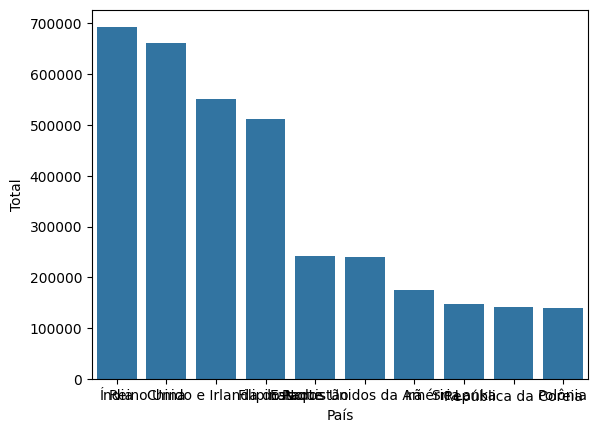

In [48]:
sns.barplot(data=top_10, x=top_10.index, y='Total')

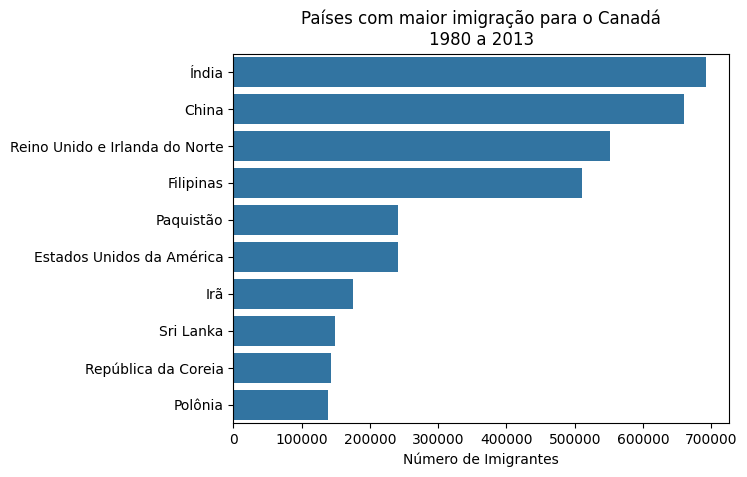

In [49]:
ax = sns.barplot(data=top_10, y=top_10.index, x='Total', orient='h')

ax.set(title="Países com maior imigração para o Canadá\n1980 a 2013",
       xlabel='Número de Imigrantes',
        ylabel='')

plt.show()

In [50]:
# função para inserir uma paleta de cores no gráfico
def gerar_grafico_paleta(palette):
    fig, ax = plt.subplots(figsize=(8,4))
    ax = sns.barplot(data=top_10, y=top_10.index, x='Total', orient='h', palette=palette)
    ax.set_title('Países com maior imigração para o Canadá\n1980 a 2013', loc='left', fontsize=18)
    ax.set_xlabel('Número de imigrantes', fontsize=14)
    ax.set_ylabel('')
    plt.show()

/tmp/ipykernel_61843/782384831.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_10, y=top_10.index, x='Total', orient='h', palette=palette)


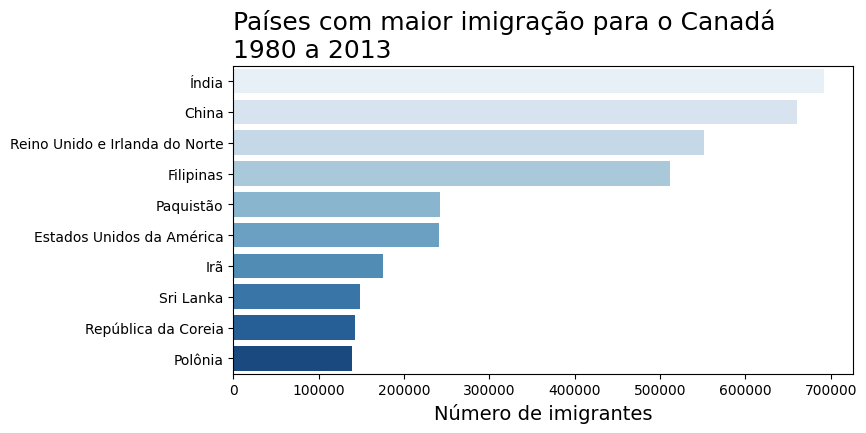

In [51]:
gerar_grafico_paleta('Blues')

/tmp/ipykernel_61843/782384831.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_10, y=top_10.index, x='Total', orient='h', palette=palette)


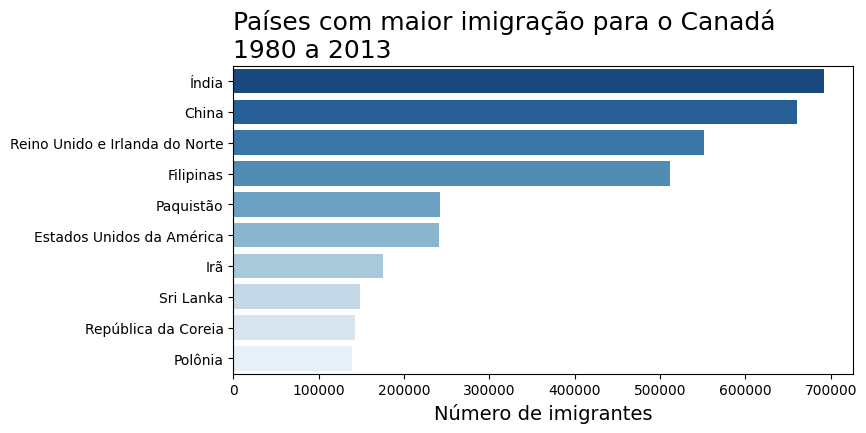

In [52]:
gerar_grafico_paleta('Blues_r')

/tmp/ipykernel_61843/782384831.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_10, y=top_10.index, x='Total', orient='h', palette=palette)


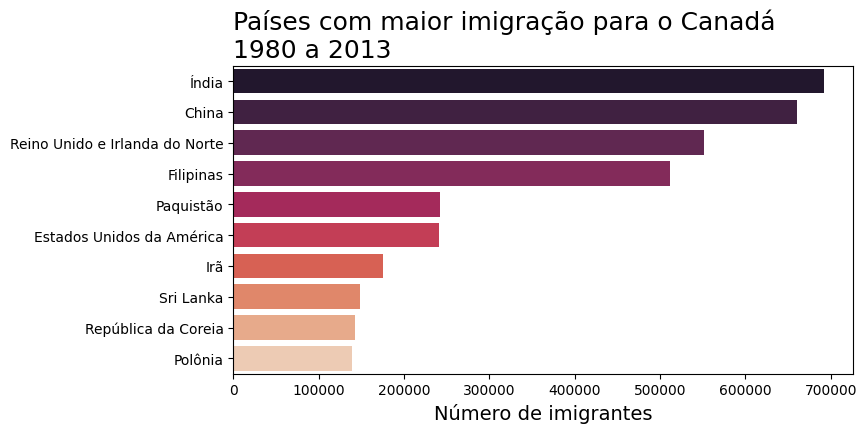

In [53]:
gerar_grafico_paleta('rocket')

/tmp/ipykernel_61843/782384831.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_10, y=top_10.index, x='Total', orient='h', palette=palette)


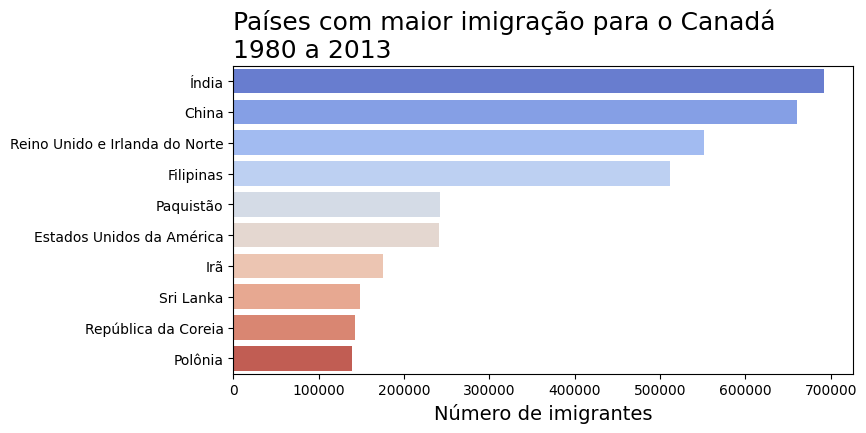

In [54]:
gerar_grafico_paleta('coolwarm')

/tmp/ipykernel_61843/782384831.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_10, y=top_10.index, x='Total', orient='h', palette=palette)


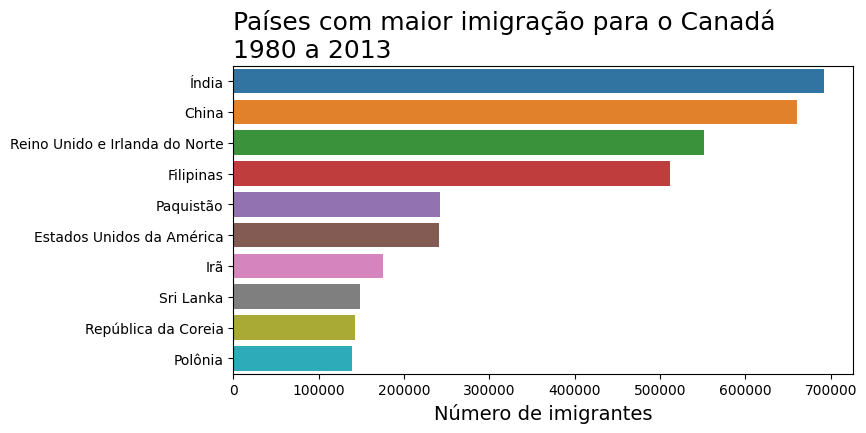

In [55]:
gerar_grafico_paleta("tab10")

/tmp/ipykernel_61843/782384831.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_10, y=top_10.index, x='Total', orient='h', palette=palette)


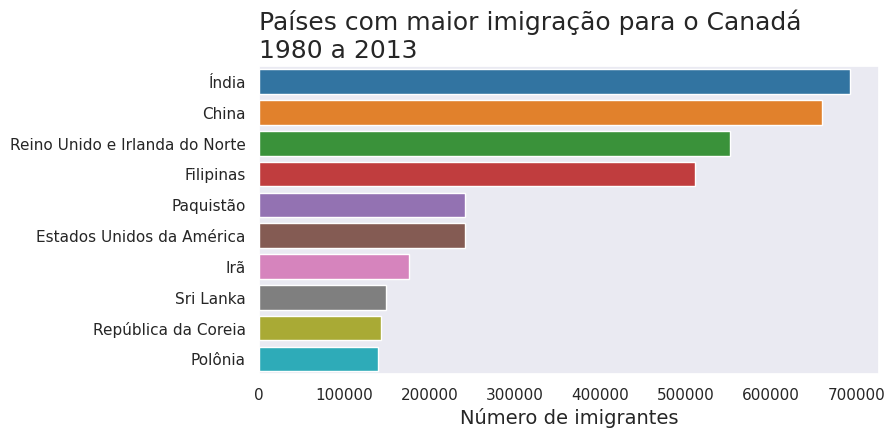

In [56]:
sns.set_theme(style='dark')
gerar_grafico_paleta("tab10")

/tmp/ipykernel_61843/782384831.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_10, y=top_10.index, x='Total', orient='h', palette=palette)


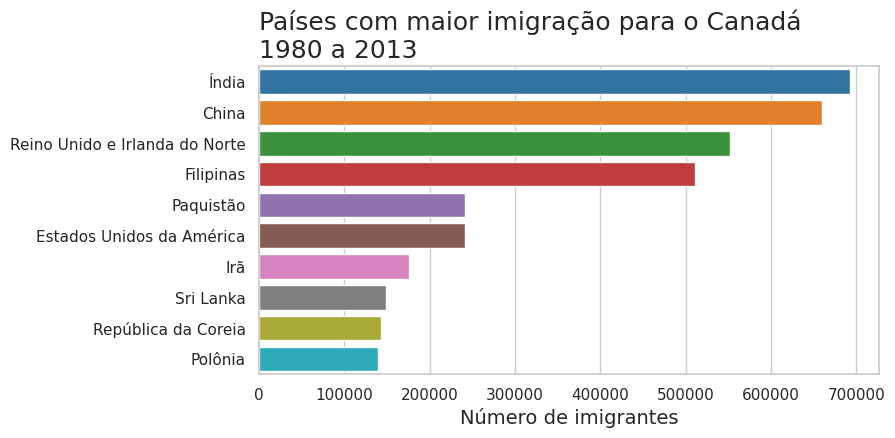

In [57]:
sns.set_theme(style='whitegrid')
gerar_grafico_paleta("tab10")

/tmp/ipykernel_61843/782384831.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_10, y=top_10.index, x='Total', orient='h', palette=palette)


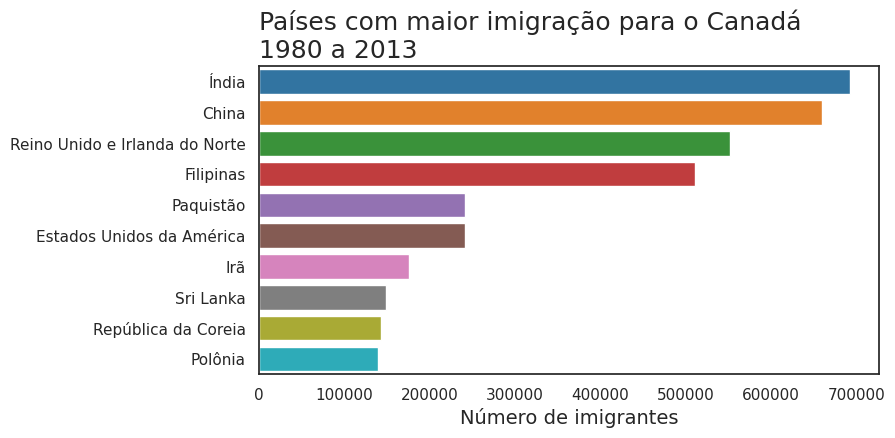

In [58]:
sns.set_theme(style='white')
gerar_grafico_paleta("tab10")

/tmp/ipykernel_61843/782384831.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_10, y=top_10.index, x='Total', orient='h', palette=palette)


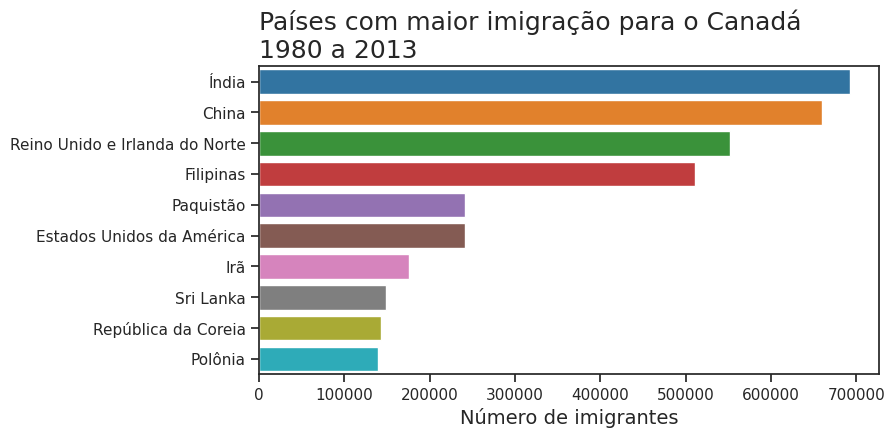

In [59]:
sns.set_theme(style='ticks')
gerar_grafico_paleta("tab10")

/tmp/ipykernel_61843/1557161652.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_10, y=top_10.index, x='Total', orient='h', palette='tab10')


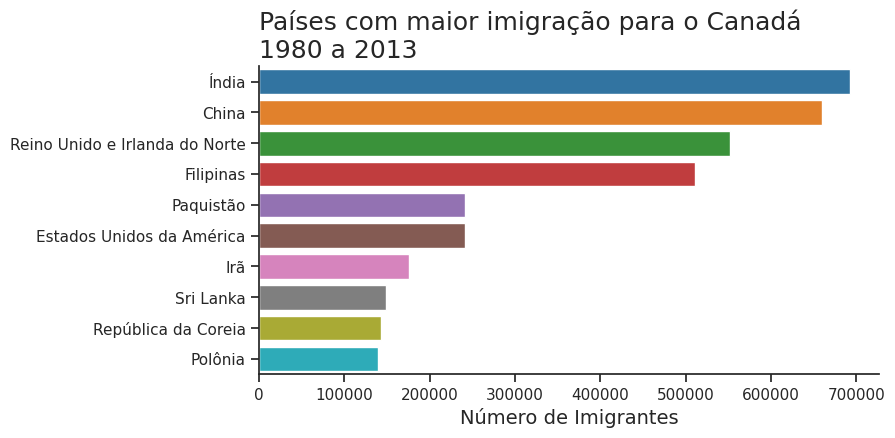

In [61]:
fig, ax = plt.subplots(figsize=(8, 4))
ax = sns.barplot(data=top_10, y=top_10.index, x='Total', orient='h', palette='tab10')

ax.set_title('Países com maior imigração para o Canadá\n1980 a 2013', loc='left', fontsize=18)
ax.set_xlabel('Número de Imigrantes', fontsize=14)
ax.set_ylabel('')
sns.despine() # para remover a linha superior e a linha à direita do gráfico

plt.show()

In [64]:
# criar uma figura contendo as tendências de imigração dos 4 maiores países da América latina: Brasil, Argentina, Peru e Colômbia

from matplotlib import colormaps
list(colormaps)

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'berlin',
 'managua',
 'vanimo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',

In [65]:
sns.set_palette('icefire')

In [66]:
df = pd.read_csv("https://raw.githubusercontent.com/alura-cursos/bibliotecas_visualizacao/refs/heads/main/Dados/imigrantes_canada.csv")
df.set_index('País', inplace=True)

In [67]:
sns.set_theme(style='whitegrid')

In [80]:
america_latina4 = df.query('País in ["Brasil", "Argentina", "Peru", "Colômbia"]')
america_latina = df.query('Continente == "América Latina e o Caribe"')
america_latina4

,Continente,Região,1980,1981,1982,1983,1984,1985,1986,1987,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
País,,,,,,,,,,,,,,,,,,,,,
Argentina,América Latina e o Caribe,América do Sul,368,426,626,241,237,196,213,519,...,1153,847,620,540,467,459,278,263,282,19596
Brasil,América Latina e o Caribe,América do Sul,211,220,192,139,145,130,205,244,...,969,1181,1746,2138,2509,2598,1508,1642,1714,29659
Colômbia,América Latina e o Caribe,América do Sul,266,326,360,244,235,214,257,376,...,6424,6535,5357,5452,4652,5218,4366,3741,3631,72088
Peru,América Latina e o Caribe,América do Sul,317,456,401,241,306,328,628,843,...,1653,1473,1490,1094,1884,1283,886,787,682,32652


In [88]:
america_latina4_sorted = america_latina4.sort_values('Total', ascending=False)

/tmp/ipykernel_61843/780122841.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=america_latina4_sorted, y=america_latina4_sorted.index, x='Total', orient='h', palette='icefire')


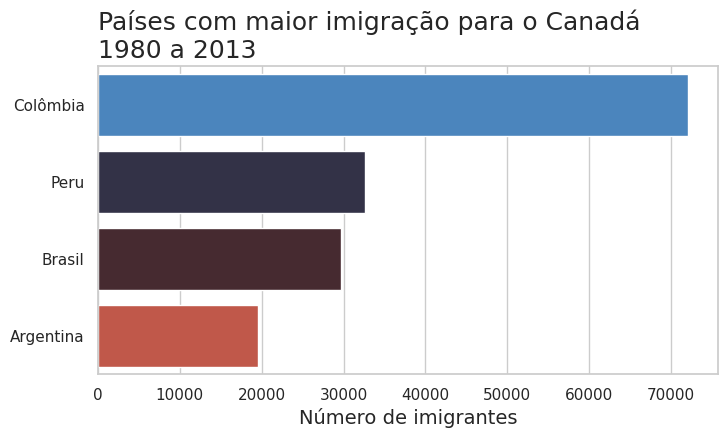

In [89]:
fig, ax = plt.subplots(figsize=(8,4))
ax = sns.barplot(data=america_latina4_sorted, y=america_latina4_sorted.index, x='Total', orient='h', palette='icefire')
ax.set_title('Países com maior imigração para o Canadá\n1980 a 2013', loc='left', fontsize=18)
ax.set_xlabel('Número de imigrantes', fontsize=14)
ax.set_ylabel('')

fig.savefig('imigracao_america_latina.png', transparent=False, dpi=300, bbox_inches='tight')

plt.show()

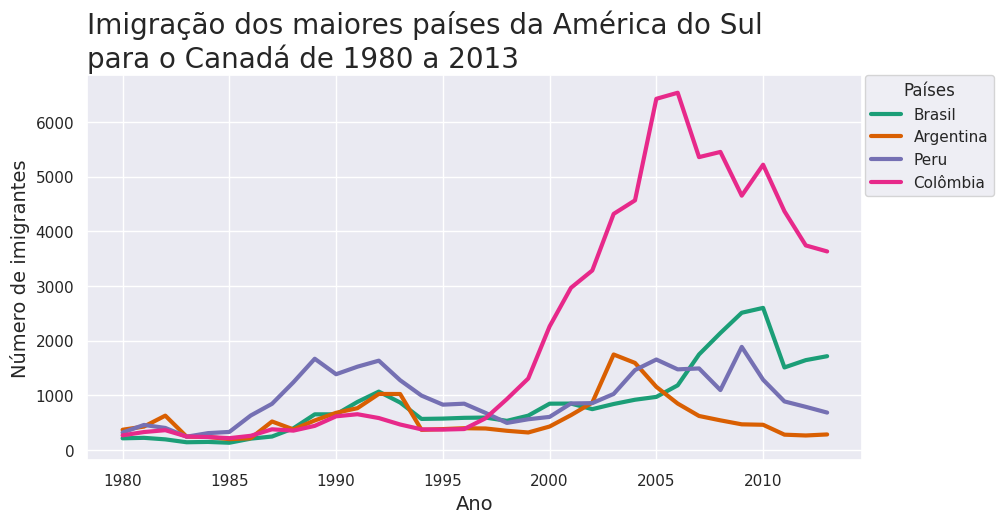

In [91]:
sns.set_theme()
sns.set_palette('Dark2')

fig, ax = plt.subplots(figsize=(10, 5))
ax = sns.lineplot(df.loc['Brasil', anos], label='Brasil', lw=3)
ax = sns.lineplot(df.loc['Argentina', anos], label='Argentina', lw=3)
ax = sns.lineplot(df.loc['Peru', anos], label='Peru', lw=3)
ax = sns.lineplot(df.loc['Colômbia', anos], label='Colômbia', lw=3)

ax.set_title('Imigração dos maiores países da América do Sul\npara o Canadá de 1980 a 2013', loc='left', fontsize=20)
ax.set_xlabel('Ano', fontsize=14)
ax.set_ylabel('Número de imigrantes', fontsize=14)

ax.xaxis.set_major_locator(plt.MultipleLocator(5))

ax.legend(title='Países', loc='upper right', bbox_to_anchor=(1.18, 1.02))

plt.show()